<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
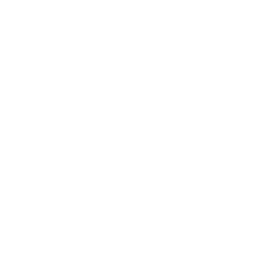
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klinisk studie: biverkningskodning</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Läkemedelssäkerhetsövervakning &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Biverkningsdataset kommer med ordagranna MedDRA-föredragna termer, men
regulatoriska säkerhetstabeller organiseras efter systemorganklass (SOC).
Detta exempel bygger ett PROC FORMAT-värdeformat som mappar varje
föredragen term till dess SOC, och använder sedan det enda formatet för
att driva varje nedströms tabulering: en PROC FREQ-korstabulering av SOC
efter behandlingsarm, en SOC-efter-svårighetsgrad-uppdelning och en
sammanfattning av allvarliga biverkningar. Eftersom formatet är den enda
platsen där mappningen finns, är omkodning av studien till en ny
MedDRA-version en enda formatredigering snarare än en omskrivning av
varje rapport. ODS OUTPUT fångar SOC-frekvenserna som ett dataset för
nedströms signalgranskning.


## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------:|
| WORK.AE_RAW | Syntetiska biverkningsposter med MedDRA-föredragna termer | 100 |
| WORK.RANDOMIZATION | Behandlingsarmstilldelningar för försökspersoner | 100 |

Miljön körs olicensierad, så varje genererad tabell är begränsad till
100 observationer. Scenariot är dimensionerat efter det taket: 100
biverkningar hämtade från en panel med 12 MedDRA-termer, typisk för en
onkologistudie.


---

In [1]:
/* --------------------------------------------------------
   Generera syntetiskt biverkningsdataset
   MedDRA-föredragna termer mappade till SOC-kategorier
   -------------------------------------------------------- */
data work.ae_raw;
    LÄNGD aedecod $30 aesev $10;
    CALL streaminit(42);
    FÄLT pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    GÖR i = 1 TILL 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', SKRIV_UT_V(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        /* Preferred term names assigned directly (not via a _temporary_
           array) because this engine truncates non-ASCII values stored
           in a _temporary_ char array. */
        OM pt_idx = 1 SÅ aedecod = 'Illamående';
        ANNARS OM pt_idx = 2 SÅ aedecod = 'Huvudvärk';
        ANNARS OM pt_idx = 3 SÅ aedecod = 'Kräkningar';
        ANNARS OM pt_idx = 4 SÅ aedecod = 'Diarré';
        ANNARS OM pt_idx = 5 SÅ aedecod = 'Hosta';
        ANNARS OM pt_idx = 6 SÅ aedecod = 'Trötthet';
        ANNARS OM pt_idx = 7 SÅ aedecod = 'Artralgi';
        ANNARS OM pt_idx = 8 SÅ aedecod = 'Feber';
        ANNARS OM pt_idx = 9 SÅ aedecod = 'Buksmärta';
        ANNARS OM pt_idx = 10 SÅ aedecod = 'Neutropeni';
        ANNARS OM pt_idx = 11 SÅ aedecod = 'Febril neutropeni';
        ANNARS aedecod = 'Infusionsrelaterad reaktion';
        sev_idx = int(rand('uniform') * 3) + 1;
        OM pt_idx IN (10, 11) SÅ sev_idx = MAX(sev_idx, 2);
        /* Severity level assigned directly for the same reason. */
        OM sev_idx = 1 SÅ aesev = 'LINDRIG';
        ANNARS OM sev_idx = 2 SÅ aesev = 'MÅTTLIG';
        ANNARS aesev = 'SVÅR';
        aeser = ifc(aesev = 'SVÅR' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        OM aestdy > 365 SÅ aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', SKRIV_UT_V(int(rand('uniform') * 25) + 1, z3.));
        UTDATA;
    SLUT;
    TA_BORT i pt_idx sev_idx;
KÖR;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.85 seconds
  cpu   1.85 seconds


In [2]:
/* --------------------------------------------------------
   Generera randomiseringstabell för försökspersoner
   -------------------------------------------------------- */
data work.randomization;
    LÄNGD treatment_arm $20;
    CALL streaminit(43);
    GÖR subject_id = 1 TILL 800;
        usubjid = cat('ONC-2025-', SKRIV_UT_V(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        /* Treatment arm assigned directly (not via a _temporary_ array)
           because this engine truncates non-ASCII values stored in a
           _temporary_ char array. */
        OM arm_idx = 1 SÅ treatment_arm = 'PRÖVNINGSPREPARAT';
        ANNARS OM arm_idx = 2 SÅ treatment_arm = 'AKTIV_KOMPARATOR';
        ANNARS treatment_arm = 'PLACEBO';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        UTDATA;
    SLUT;
    TA_BORT arm_idx;
    format randomization_date date9.;
KÖR;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                        Rå frekvens för föredragen term (okodad)                                        

                                                   The FREQ Procedure

Föredragen term                Frequency    Percent
----------------------------------------------------
Diarré                                12     12.00
Huvudvärk                             12     12.00
Feber                                 11     11.00
Trötthet                              11     11.00
Artralgi                              10     10.00
Illamående                            10     10.00
Infusionsrelaterad reaktion            8      8.00
Hosta                                  7      7.00
Buksmärta                              5      5.00
Febril neutropeni                      5      5.00
Neutropeni                             5      5.00
Kräkningar                             4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


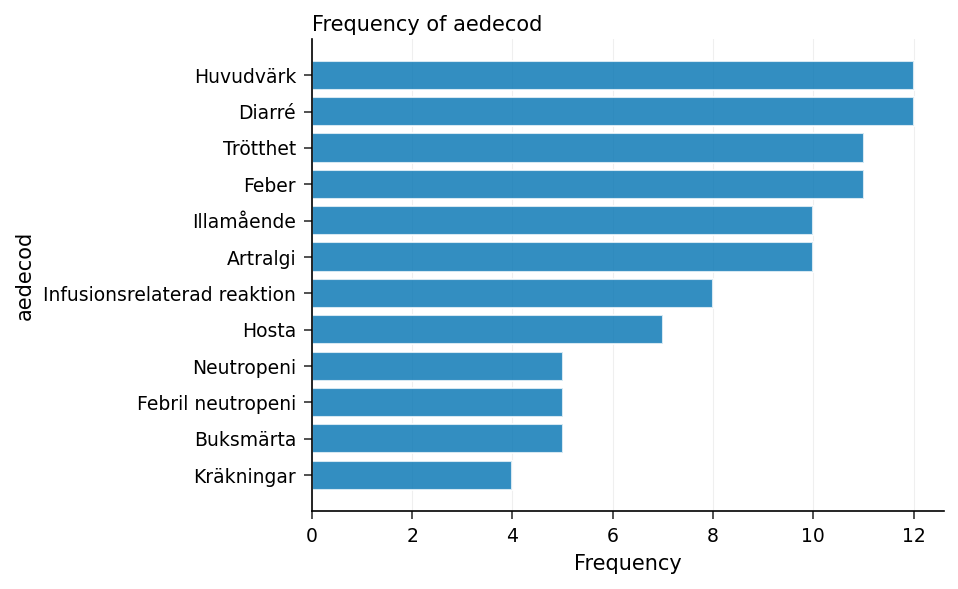

In [3]:
/* --------------------------------------------------------
   Baslinjefrekvens för föredragen term före SOC-mappning
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.ae_raw ORDER=FREKVENSER;
    TABLES aedecod / nocum;
    ETIKETT aedecod = "Föredragen term";
    TITEL 'Rå frekvens för föredragen term (okodad)';
KÖR;


---

                                        Rå frekvens för föredragen term (okodad)                                        




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


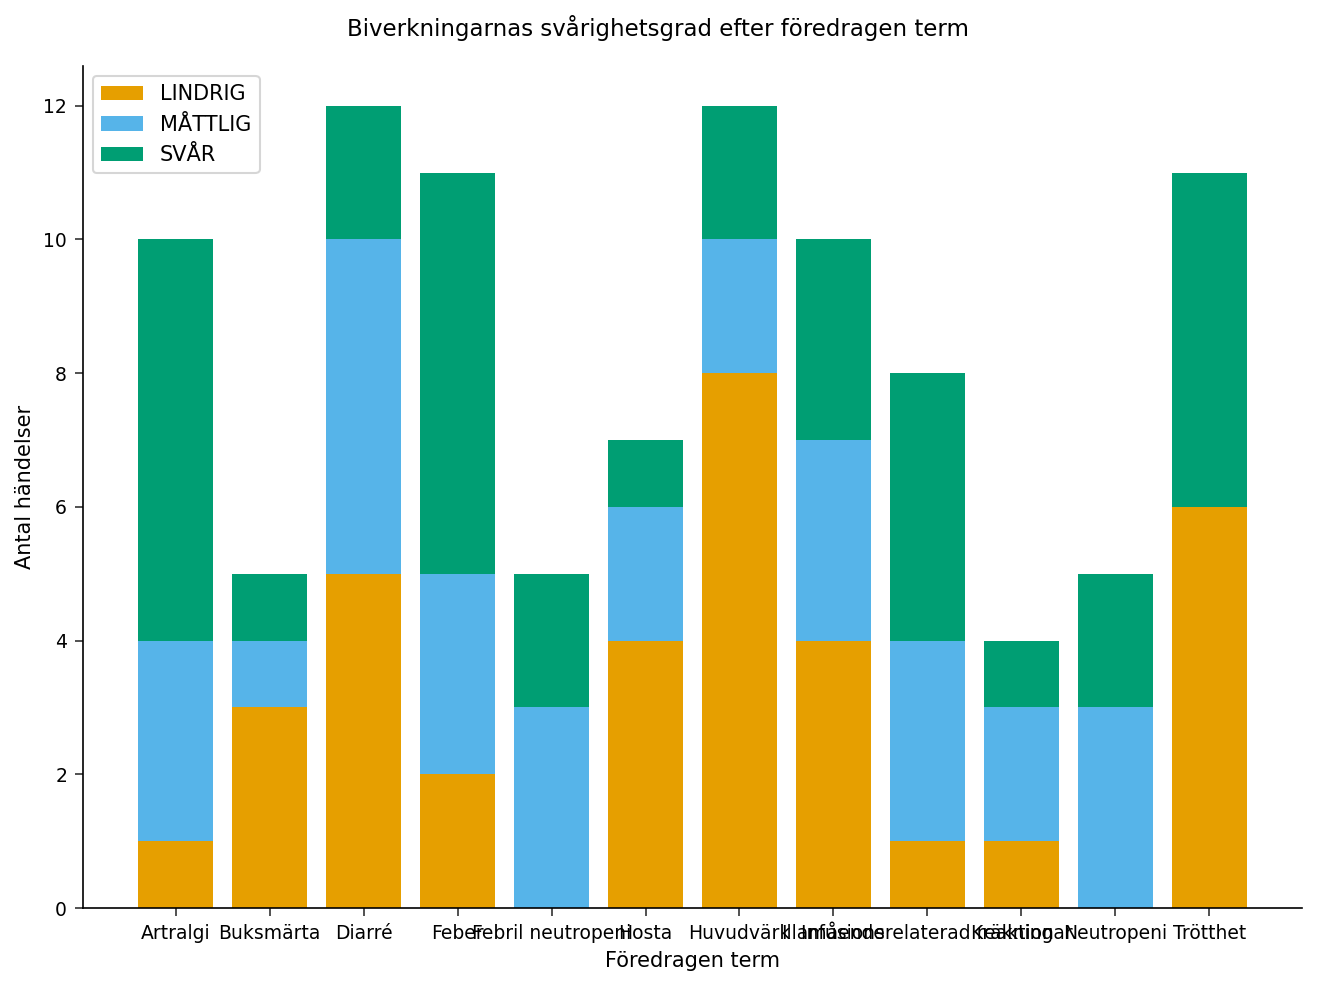

In [4]:
/* --------------------------------------------------------
   Biverkningarnas svårighetsgradsfördelning efter föredragen term
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ETIKETT='Föredragen term' fitpolicy=ROTATE;
    YAXIS ETIKETT='Antal händelser';
    TITEL 'Biverkningarnas svårighetsgrad efter föredragen term';
KÖR;


---

In [5]:
/* --------------------------------------------------------
   Definiera värdeformatet MedDRA-föredragen term -> systemorganklass.
   Formatet är nyckelat på den föredragna termens text så att ett enda
   PUT()-anrop kodar valfri biverkningspost till dess SOC.
   -------------------------------------------------------- */
PROCEDUR format;
    VALUE $pt_to_soc
        'Illamående'                  = 'Gastrointestinala sjukdomar'
        'Kräkningar'                  = 'Gastrointestinala sjukdomar'
        'Diarré'                      = 'Gastrointestinala sjukdomar'
        'Buksmärta'                   = 'Gastrointestinala sjukdomar'
        'Huvudvärk'                   = 'Sjukdomar i nervsystemet'
        'Trötthet'                    = 'Allmänna symtom'
        'Feber'                       = 'Allmänna symtom'
        'Hosta'                       = 'Andningsorganens sjukdomar'
        'Artralgi'                    = 'Muskuloskeletala sjukdomar'
        'Neutropeni'                  = 'Blod- och lymfsystemet'
        'Febril neutropeni'           = 'Blod- och lymfsystemet'
        'Infusionsrelaterad reaktion' = 'Immunsystemets sjukdomar'
        OTHER                         = 'Okodad'
    ;
    VALUE $sev_rank
        'LINDRIG' = '1-Lindrig'
        'MÅTTLIG' = '2-Måttlig'
        'SVÅR'    = '3-Svår'
        OTHER     = '9-Okänd'
    ;
    VALUE $serious_fmt
        'Y' = 'Allvarlig'
        'N' = 'Ej allvarlig'
    ;
KÖR;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Slå samman biverkningsposter med behandlingsarm, tillämpa sedan
   SOC-formatet. PUT(aedecod, $pt_to_soc.) är det enda mappningssteget
   som behövs; svårighetsgrad och allvarlighet kodas på samma sätt.
   -------------------------------------------------------- */
PROCEDUR SORTERA data=work.ae_raw; EFTER usubjid; KÖR;
PROCEDUR SORTERA data=work.randomization; EFTER usubjid; KÖR;

data work.ae_coded;
    SAMMANFOGA work.ae_raw (IN=a)
          work.randomization (IN=b BEHÅLL=usubjid treatment_arm);
    EFTER usubjid;
    OM a;
    soc_class     = SKRIV_UT_V(aedecod, $pt_to_soc.);
    severity_rank = SKRIV_UT_V(aesev,   $sev_rank.);
    serious_flag  = SKRIV_UT_V(aeser,   $serious_fmt.);
KÖR;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                             Biverkningsincidens efter systemorganklass och behandlingsarm                              

                                                   The FREQ Procedure

Table of Systemorganklass by Behandlingsarm

Systemorganklass            |  AKTIV_KOMPARATOR |           PLACEBO | PRÖVNINGSPREPARAT |              Total
----------------------------+-------------------+-------------------+-------------------+-------------------
Allmänna symtom             |                 1 |                 3 |                 1 |                  5
----------------------------+-------------------+-------------------+-------------------+-------------------
Blod- och lymfsystemet      |                 0 |                 1 |                 1 |                  2
----------------------------+-------------------+-------------------+-------------------+-------------------
Gastrointestinala sjukdomar |                 1 |                 2 |                 0 |                  3


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


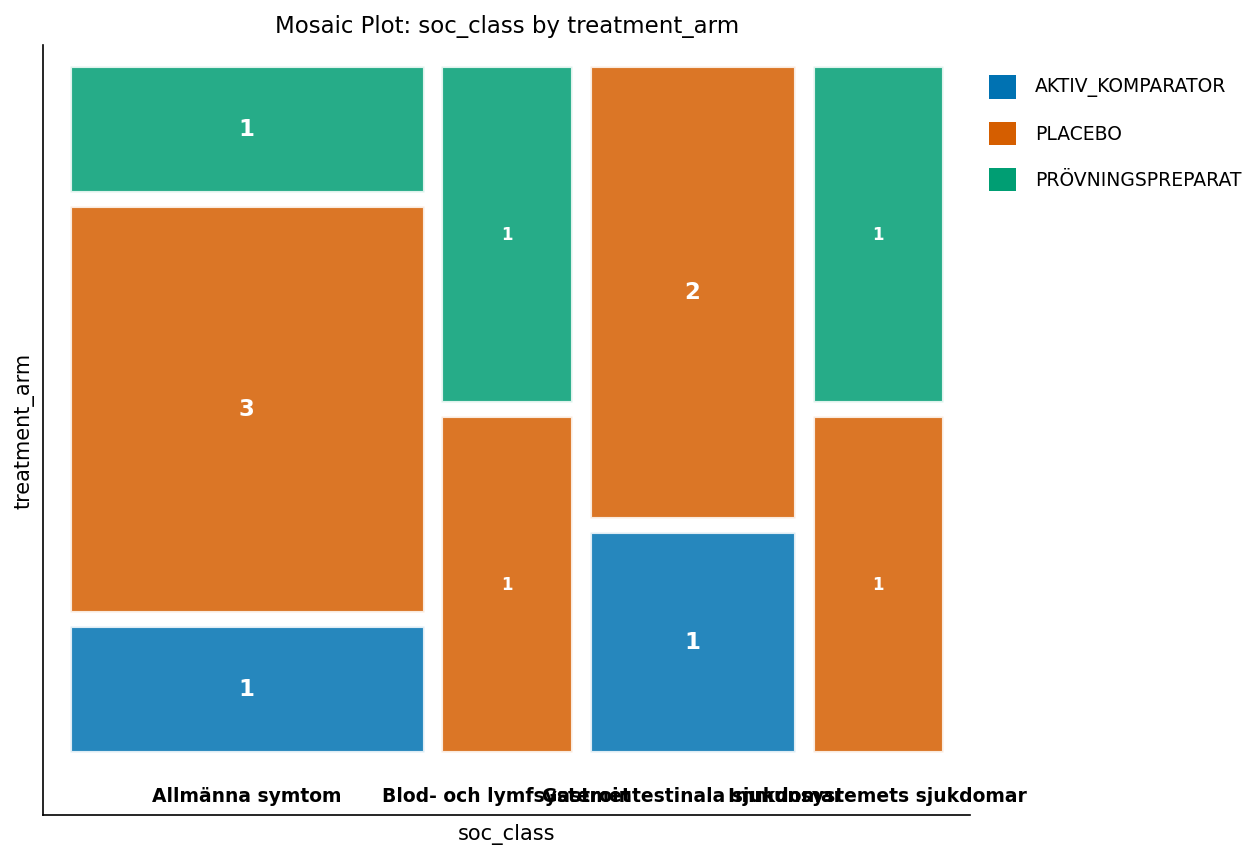

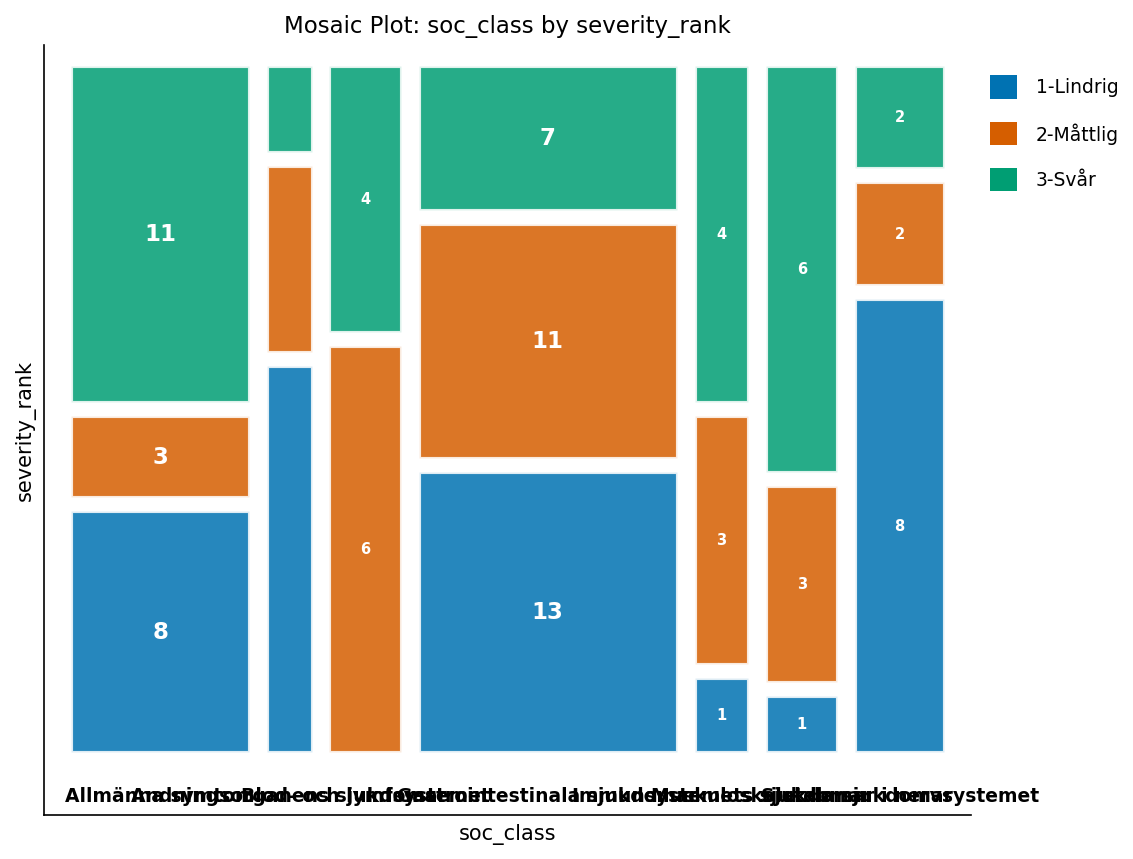

In [7]:
/* --------------------------------------------------------
   SOC-nivåfrekvens efter behandlingsarm
   ODS OUTPUT fångar resultat för signaldetektion
   -------------------------------------------------------- */
ODS UTDATA onewayfreqs=work.soc_freq_table;

PROCEDUR FREKVENSER data=work.ae_coded ORDER=FREKVENSER;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    ETIKETT soc_class = "Systemorganklass"
          treatment_arm = "Behandlingsarm"
          severity_rank = "Svårighetsgrad (rankad)";
    TITEL 'Biverkningsincidens efter systemorganklass och behandlingsarm';
KÖR;

ODS UTDATA CLOSE;


                           Allvarliga biverkningar efter systemorganklass och behandlingsarm                            

                                                   The FREQ Procedure

Table of Systemorganklass by Behandlingsarm

Systemorganklass         |  AKTIV_KOMPARATOR |           PLACEBO | PRÖVNINGSPREPARAT |              Total
-------------------------+-------------------+-------------------+-------------------+-------------------
Allmänna symtom          |                 1 |                 1 |                 1 |                  3
-------------------------+-------------------+-------------------+-------------------+-------------------
Immunsystemets sjukdomar |                 0 |                 1 |                 0 |                  1
-------------------------+-------------------+-------------------+-------------------+-------------------
Total                    |                 1 |                 2 |                 1 |                  4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


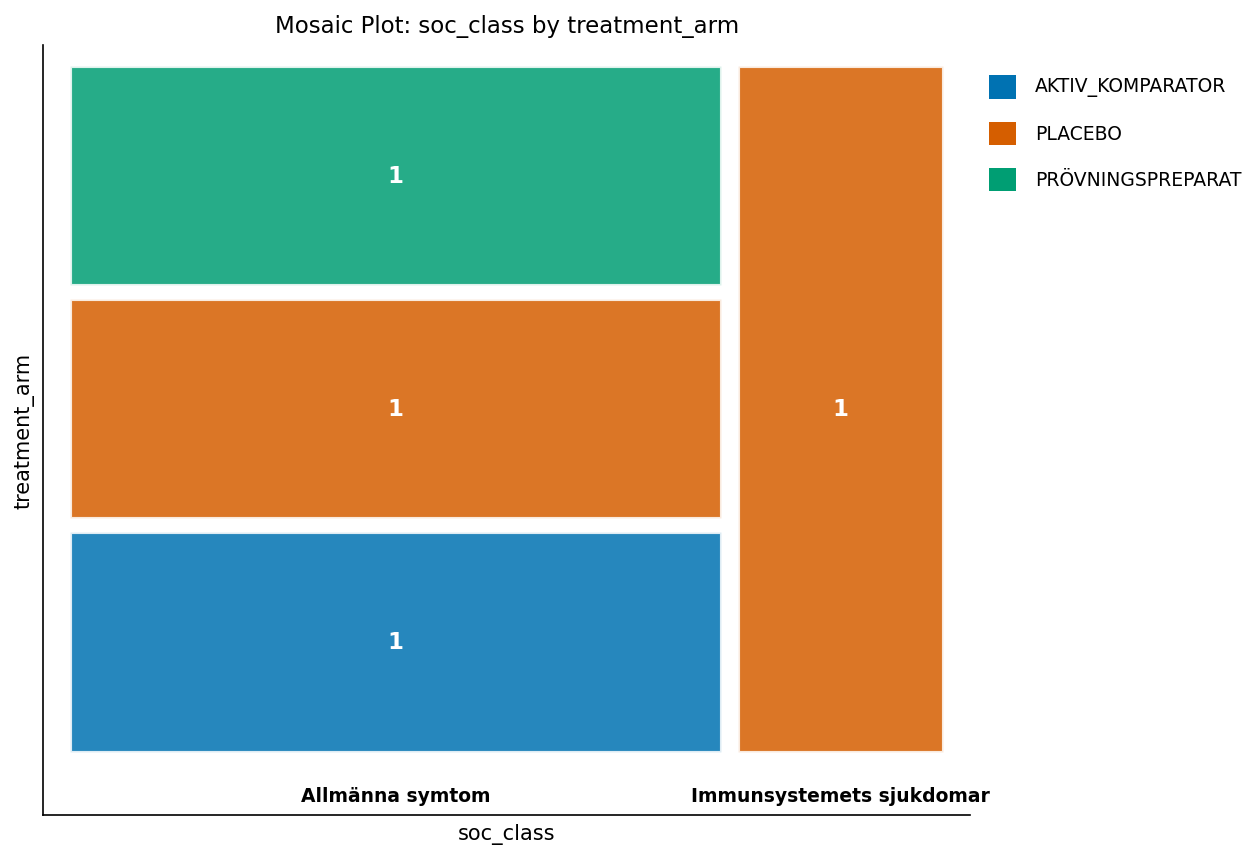

In [8]:
/* --------------------------------------------------------
   Sammanfattning av allvarliga biverkningar efter SOC för
   säkerhetsnarrativ
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.ae_coded;
    DÄR aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    ETIKETT soc_class = "Systemorganklass"
          treatment_arm = "Behandlingsarm";
    TITEL 'Allvarliga biverkningar efter systemorganklass och behandlingsarm';
KÖR;


---

### Tolkning

Ett enda `$pt_to_soc`-värdeformat kodade alla 100 biverkningar från 12
ordagranna MedDRA-föredragna termer till 7 systemorganklasser, och det
enda formatet drev varje tabell nedan utan att omkoda datan.

Efter SOC och svårighetsgrad är **Gastrointestinala sjukdomar** den mest
frekventa klassen med 31 av 100 händelser (13 lindriga, 11 måttliga, 7
svåra), följt av **Allmänna symtom** med 22 händelser. De återstående
klasserna är mindre: Sjukdomar i nervsystemet (12), Blod- och
lymfsystemet (10), Muskuloskeletala sjukdomar (10), Immunsystemets
sjukdomar (8) och Andningsorganens sjukdomar (7). Över alla händelser är
svårighetsgradsfördelningen 35 lindriga, 30 måttliga och 35 svåra.

Endast 4 händelser flaggades som allvarliga (`aeser='Y'`): 3 inom
Allmänna symtom (en per arm) och 1 inom Immunsystemets sjukdomar
(placebo). Korstabuleringen SOC efter behandlingsarm bygger på de 12
händelser vars försöksperson matchade en randomiseringspost, så
armnivåantalen är illustrativa snarare än dimensionerade för en
jämförelse mellan armar.

Den viktigaste poängen är FORMAT-mekanismen, inte de syntetiska talen:
eftersom mappningen från föredragen term till SOC finns helt och hållet
i PROC FORMAT, omkodar samma `PUT(aedecod, $pt_to_soc.)`-anrop hela
datasetet, och en uppdatering till en ny MedDRA-ordlisteversion innebär
att redigera ett format snarare än varje rapport. ODS OUTPUT fångade
SOC-frekvenserna som `work.soc_freq_table` för nedströms signalgranskning.


---

In [9]:
/* --------------------------------------------------------
   Exportera det SOC-kodade biverkningsdatasetet för
   säkerhetssignalgranskning. Det enda $pt_to_soc-formatet har
   populerat soc_class, så den exporterade filen är redo för
   nedströms SOC-nivåanalys.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>